In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_final.csv')

price_col = 'price'
bed_col = 'beds'

In [2]:
print(df['price'].mean() )
print(df['price'].median() )

1372109.4021894336
495000.0


In [3]:
# capping at 10 only hides a small portion of the data from the graphics, but largely improves visibility
# creates a dataset with just the columns we want for eda
eda = df[["price", "beds", "baths", "area_sqft"]].copy()

# data integrity, prevents errors (should only be a few missing area_sqft rows, but no missing datapoints for price, beds, or baths )
eda = eda.dropna()

# breakdown for charts
# reasonable to cap at 10 bedrooms since greater than 10 bedrooms has one or two homes, would skew chart of extremely high priced outliers
eda['beds'].value_counts()

beds
3     838
4     767
5     214
2     131
6      49
7      17
1      15
8       7
10      5
11      2
13      2
12      1
16      1
18      1
9       1
14      1
17      1
Name: count, dtype: int64

In [4]:
# log buckets setup
bins = [
    0,
    100000,
    1000000,
    10000000,
    np.inf
]

# log bucket labels
labels = [
    "<$100K",
    "$100K–<$1M",
    "$1M–<$10M",
    "$10M+"
]

df["price_bucket"] = pd.cut(
    df[price_col],
    bins=bins,
    labels=labels
)

# aggregate buckets
home_count = df["price_bucket"].value_counts().sort_index()

# keep rounding at 1-2 decimals max, otherwise the chart will prob become difficult to read
percents = home_count / len(df) * 100
percents = round(percents, 1)

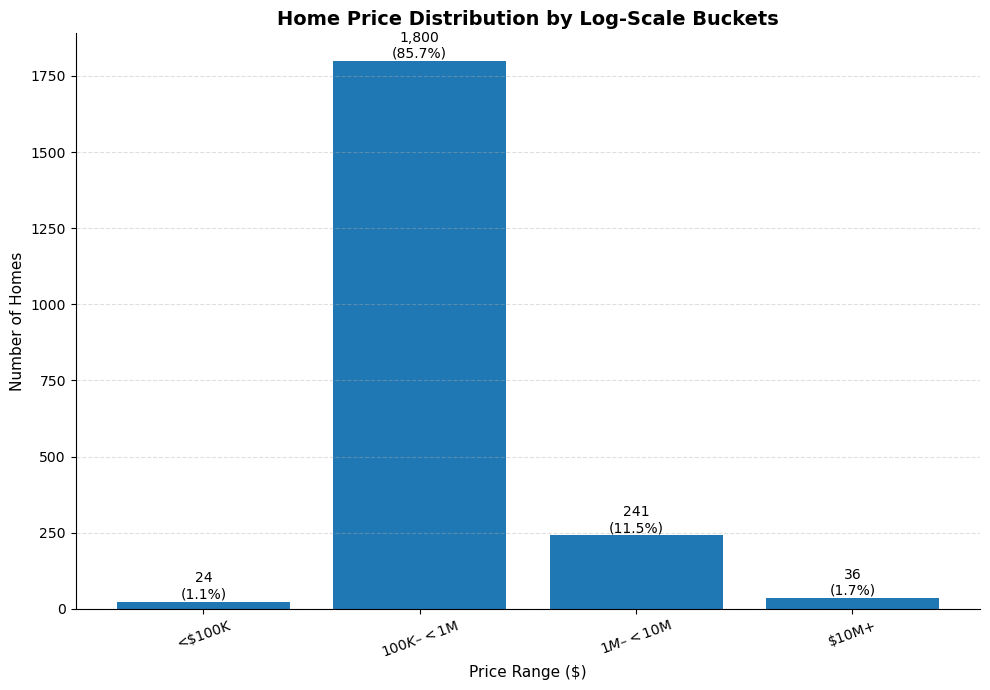

In [5]:
# Home Price Distribution by Log-Scale Buckets Bar Chart
plt.figure(figsize=(10, 7))

bars = plt.bar(
    home_count.index.astype(str),
    home_count.values
)

# Labels: title, x, and y axes
plt.title("Home Price Distribution by Log-Scale Buckets", fontsize=14, weight="bold")
plt.xlabel("Price Range ($)", fontsize=11)
plt.ylabel("Number of Homes", fontsize=11)

# format axes
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)

# removes top and right border/edge so the 85.7% value does not overlap
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# formatting for the bar labels
for bar, count, pct in zip(bars, home_count.values, percents.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,}\n({pct}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="medium"
    )

plt.tight_layout()
plt.show()

In [6]:
# Bedroom Analysis setup

# price cap for outliers, readability (this only affects bedroom counts 8-10)
eda_q_95 = eda[eda["price"] <= eda["price"].quantile(0.95)]
eda_q_95 = eda_q_95[eda_q_95['beds'] <= 10] # capped for consistency with average home price chart so both show 1-10 bedrooms

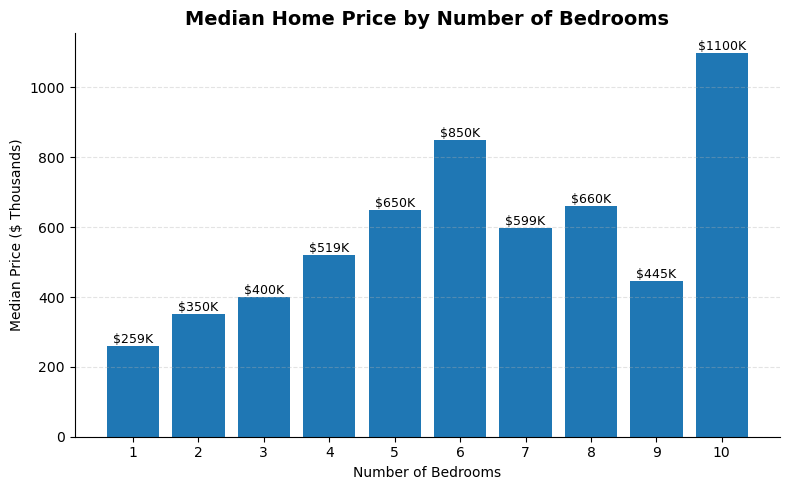

In [7]:
# Median home price by bedrooms chart

bed_summary = eda_q_95.groupby("beds")["price"].median()
bed_summary_k = bed_summary / 1000 # lists price in thousands, for readability 

plt.figure(figsize=(8, 5))

bars = plt.bar(bed_summary.index.astype(str), bed_summary_k.values)

# labels
plt.title("Median Home Price by Number of Bedrooms", fontsize=14, weight="bold")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Median Price ($ Thousands)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# top and right side borders removed
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(bars, bed_summary.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"${value/1000:.0f}K",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

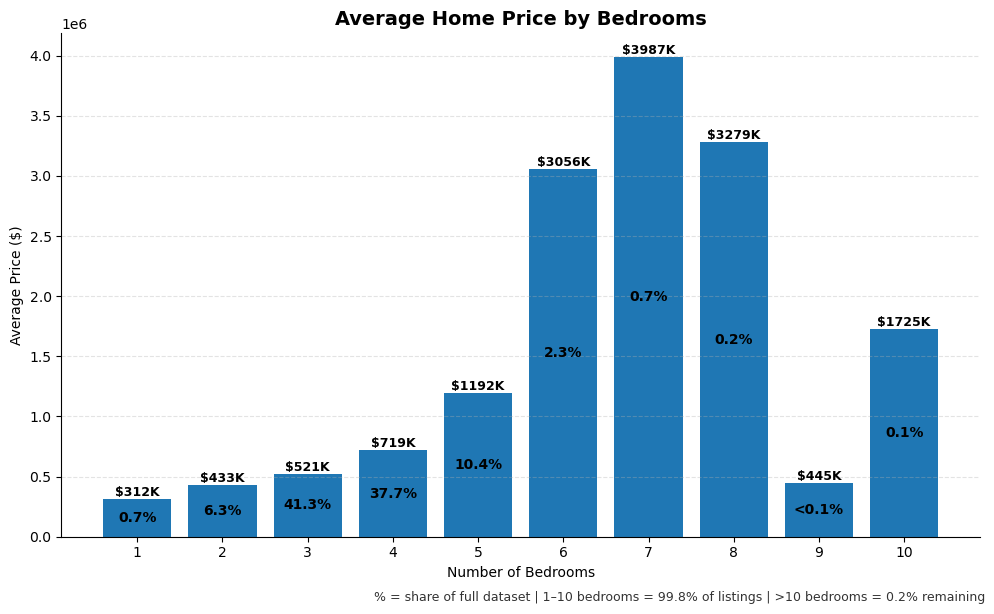

In [8]:
# Keep this here even though the chart is unknown since calculations are compiled within this block

# Optional: cap price outliers for cleaner average-price visualization
eda = df[df[price_col] <= df[price_col].quantile(0.99)]

# Separate 1–10 bedroom homes from 10+ bedroom homes
eda_1_10 = eda[(eda[bed_col] >= 1) & (eda[bed_col] <= 10)].copy()
eda_over_10 = eda[eda[bed_col] > 10].copy()

pct_1_10 = len(eda_1_10) / len(eda) * 100
pct_over_10 = len(eda_over_10) / len(eda) * 100

# Summary for bedrooms 1–10 only
summary = (
    eda_1_10.groupby(bed_col)
    .agg(
        avg_price=(price_col, "mean"),
        count=(price_col, "size")
    )
    .reindex(range(1, 11), fill_value=0)
)

# calculate percent of homes in bucket
summary["percent"] = summary["count"] / len(eda) * 100

# percentage label formatting, prevents issues with 0.1 and 0.0
def format_pct(x):
    return "<0.1%" if round(x, 1) == 0.0 and x > 0 else f"{x:.1f}%"

summary["pct_label"] = summary["percent"].apply(format_pct)

# plot formatting starts here
plt.figure(figsize=(10, 6))

bars = plt.bar(summary.index.astype(str), summary["avg_price"])

# labels for title, x, and y axes
plt.title("Average Home Price by Bedrooms", fontsize=14, weight="bold")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price ($)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

# removes top and right borders so text does not overlap
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# labels
for bar, price, pct in zip(
    bars,
    summary["avg_price"],
    summary["pct_label"]
):
    # percent labels
    if price > 0:
        plt.text(
            # percentage weight for each bar
            bar.get_x() + bar.get_width() / 2,
            price * 0.50,
            pct,
            ha="center",
            va="center",
            fontsize=10,
            color="black",
            weight="bold"
        )

        # avg price labels
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            price,
            f"${price/1000:.0f}K",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight='bold'
        )

# footnote regarding datasplit
plt.figtext(
    0.99, -0.01, # Do not change these or the footer overlaps with the x axis labels
    f"% = share of full dataset | 1–10 bedrooms = {pct_1_10:.1f}% of listings | >10 bedrooms = {pct_over_10:.1f}% remaining",
    ha="right",
    fontsize=9,
    alpha=0.8
)

plt.tight_layout()
plt.show()

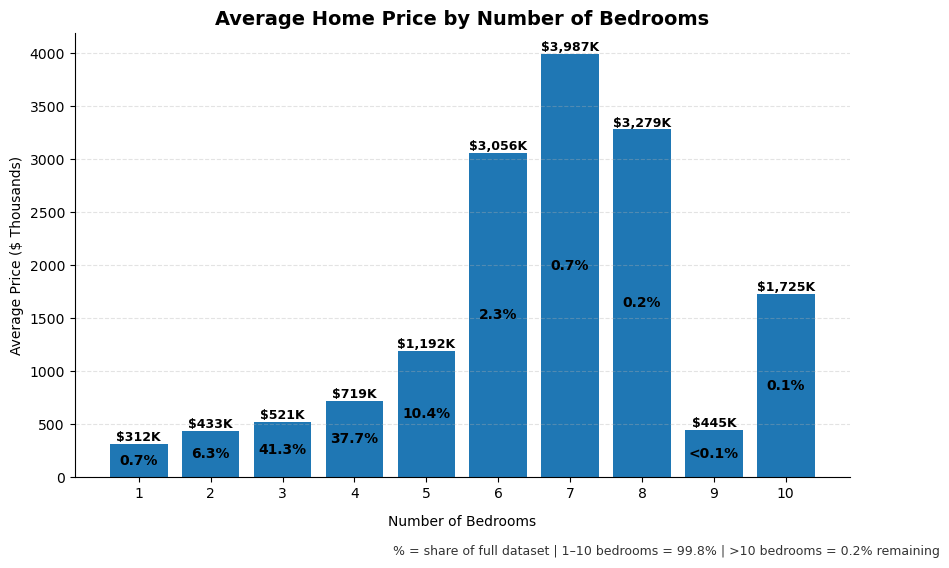

In [9]:
# Detailed average home price by bedrooms scatterplot

# convert average price to thousands, helps with readability
summary["avg_price_k"] = summary["avg_price"] / 1000

plt.figure(figsize=(10, 6))

bars = plt.bar(summary.index.astype(str), summary["avg_price_k"] )

# labels for title, x, and y axes
plt.title("Average Home Price by Number of Bedrooms", fontsize=14, fontweight="bold")
plt.xlabel("Number of Bedrooms", labelpad=10)
plt.ylabel("Average Price ($ Thousands)")

# creates gridlines for incrased readability
plt.grid(axis="y", linestyle="--", alpha=0.35)

# removes top and right border
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# labels
for bar, price_k, pct in zip(
    bars,
    summary["avg_price_k"],
    summary["pct_label"]
):
    if price_k > 0:
        # percentage weight for each bar
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            price_k * 0.50,
            pct,
            ha="center",
            va="center",
            fontsize=10,
            color="black",
            fontweight="bold"
        )

        # average price for each bar
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            price_k,
            f"${price_k:,.0f}K",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# footnote regarding datasplit
plt.figtext(
    0.99, 0.01, # do not change these numbers or formatting gets messed up
    f"% = share of full dataset | 1–10 bedrooms = {pct_1_10:.1f}% | >10 bedrooms = {pct_over_10:.1f}% remaining",
    ha="right",
    fontsize=9,
    alpha=0.8
)

# adjust bottom=X so the footnote does not overlap
plt.subplots_adjust(bottom=0.14)
plt.show()

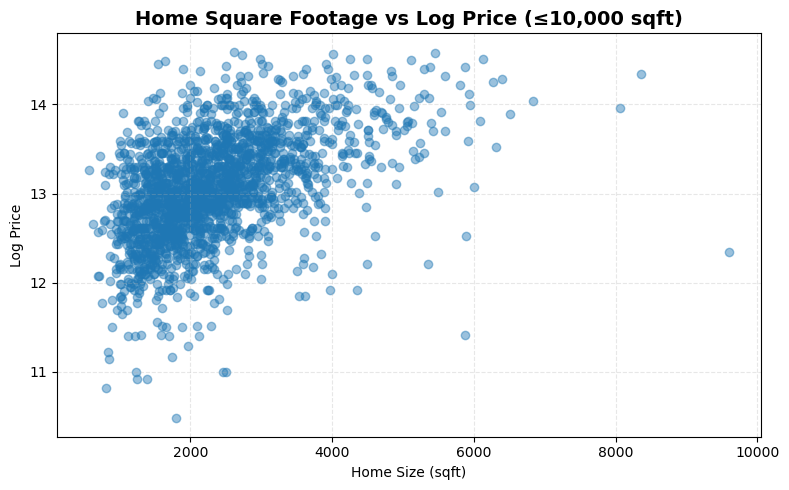

In [10]:
# Square footage log scatterplot

# caps sqft at 10k so the plot is interpretable
eda_scatter = eda_q_95[eda_q_95["area_sqft"] <= 10000].copy()
eda_scatter["log_price"] = np.log(eda_scatter["price"])

plt.figure(figsize=(8, 5))

# define x and y for scatter
plt.scatter(
    eda_scatter["area_sqft"],
    eda_scatter["log_price"],
    alpha=0.45
)

# labels for readability
plt.title("Home Square Footage vs Log Price (≤10,000 sqft)", fontsize=14, weight="bold")
plt.xlabel("Home Size (sqft)")
plt.ylabel("Log Price")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()